In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.13.0+cpu
Device: cpu


In [3]:
import random

# Special tokens
PAD = 0
SOS = 1
EOS = 2

# Normal tokens: 3 to 12
VOCAB_SIZE = 13

# Generate sequence-reversal dataset
def generate_data(num_samples=1000, min_len=3, max_len=6):
    data = []

    for _ in range(num_samples):
        length = random.randint(min_len, max_len)

        # Generate unique tokens
        sequence = random.sample(range(3, VOCAB_SIZE), length)

        source = sequence + [EOS]
        target = [SOS] + sequence[::-1] + [EOS]

        data.append((source, target))

    return data


data = generate_data(1000)

print("Number of samples:", len(data))
print("Example input :", data[0][0])
print("Example target:", data[0][1])

Number of samples: 1000
Example input : [11, 7, 3, 12, 10, 8, 2]
Example target: [1, 8, 10, 12, 3, 7, 11, 2]


In [4]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Split dataset
random.shuffle(data)

train_data = data[:800]
test_data = data[800:]

print("Training samples:", len(train_data))
print("Testing samples :", len(test_data))


class Seq2SeqDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        source, target = self.data[idx]

        return (
            torch.tensor(source, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )


def collate_fn(batch):
    sources, targets = zip(*batch)

    sources = pad_sequence(
        sources,
        batch_first=True,
        padding_value=PAD
    )

    targets = pad_sequence(
        targets,
        batch_first=True,
        padding_value=PAD
    )

    return sources, targets


train_dataset = Seq2SeqDataset(train_data)
test_dataset = Seq2SeqDataset(test_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

# Check one batch
src, trg = next(iter(train_loader))

print("Source batch shape:", src.shape)
print("Target batch shape:", trg.shape)


Training samples: 800
Testing samples : 200
Source batch shape: torch.Size([32, 7])
Target batch shape: torch.Size([32, 8])


In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)

        outputs, (hidden, cell) = self.lstm(embedded)

        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden, cell):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        output, (hidden, cell) = self.lstm(
            embedded,
            (hidden, cell)
        )

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        output_dim = self.decoder.fc_out.out_features

        outputs = torch.zeros(
            batch_size,
            trg_len,
            output_dim
        ).to(self.device)

        hidden, cell = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, cell = self.decoder(
                input_token,
                hidden,
                cell
            )

            outputs[:, t] = output

            best_guess = output.argmax(1)

            input_token = (
                trg[:, t]
                if random.random() < teacher_forcing_ratio
                else best_guess
            )

        return outputs


# Model parameters
INPUT_DIM = VOCAB_SIZE
OUTPUT_DIM = VOCAB_SIZE

ENC_EMB_DIM = 32
DEC_EMB_DIM = 32
HIDDEN_DIM = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM
)

decoder = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM
)

baseline_model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

print(baseline_model)
print("\nTrainable parameters:",
      sum(p.numel() for p in baseline_model.parameters()
          if p.requires_grad))

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(13, 32)
    (lstm): LSTM(32, 64, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(13, 32)
    (lstm): LSTM(32, 64, batch_first=True)
    (fc_out): Linear(in_features=64, out_features=13, bias=True)
  )
)

Trainable parameters: 51853


In [6]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

# Training function
def train_model(model, loader, optimizer, criterion, epochs=15):

    model.train()
    epoch_losses = []

    for epoch in range(epochs):

        total_loss = 0

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            optimizer.zero_grad()

            output = model(
                src,
                trg,
                teacher_forcing_ratio=0.5
            )

            output_dim = output.size(-1)

            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)

            loss.backward()

            # Prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1
            )

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(loader)
        epoch_losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1:02d}/15 | "
            f"Loss: {epoch_loss:.4f}"
        )

    return epoch_losses


print("Training Baseline Seq2Seq...")
baseline_losses = train_model(
    baseline_model,
    train_loader,
    optimizer,
    criterion,
    epochs=15
)

Training Baseline Seq2Seq...
Epoch 01/15 | Loss: 2.5114
Epoch 02/15 | Loss: 2.2681
Epoch 03/15 | Loss: 1.9845
Epoch 04/15 | Loss: 1.7775
Epoch 05/15 | Loss: 1.6340
Epoch 06/15 | Loss: 1.5110
Epoch 07/15 | Loss: 1.4336
Epoch 08/15 | Loss: 1.3213
Epoch 09/15 | Loss: 1.2344
Epoch 10/15 | Loss: 1.1652
Epoch 11/15 | Loss: 1.0470
Epoch 12/15 | Loss: 0.9764
Epoch 13/15 | Loss: 0.8666
Epoch 14/15 | Loss: 0.7879
Epoch 15/15 | Loss: 0.7256


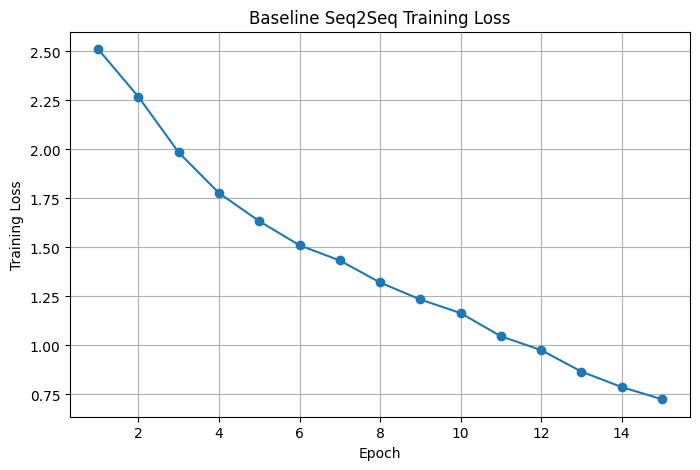

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(baseline_losses) + 1),
    baseline_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Seq2Seq Training Loss")
plt.grid(True)

plt.show()

In [8]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):

        # decoder_hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, src_len, hidden_dim]

        src_len = encoder_outputs.size(1)

        # Repeat decoder hidden state for every source position
        hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        # Calculate alignment scores
        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        attention = self.v(energy).squeeze(2)

        # Ignore padding tokens
        if mask is not None:
            attention = attention.masked_fill(mask == 0, -1e10)

        # Convert scores to probabilities
        return torch.softmax(attention, dim=1)


print("Attention module created successfully.")

Attention module created successfully.


In [9]:
class AttentionEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):
        embedded = self.embedding(src)

        # outputs contains the hidden state at every input position
        outputs, (hidden, cell) = self.lstm(embedded)

        return outputs, hidden, cell


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim
        )

        self.lstm = nn.LSTM(
            emb_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hidden_dim * 2 + emb_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs,
        mask=None
    ):

        # input_token: [batch]
        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        # Get attention weights
        attention_weights = self.attention(
            hidden[-1],
            encoder_outputs,
            mask
        )

        # Calculate context vector
        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        )

        # context: [batch, 1, hidden_dim]

        lstm_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.lstm(
            lstm_input,
            (hidden, cell)
        )

        prediction = self.fc_out(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1),
                    embedded.squeeze(1)
                ),
                dim=1
            )
        )

        return (
            prediction,
            hidden,
            cell,
            attention_weights
        )


class AttentionSeq2Seq(nn.Module):
    def __init__(
        self,
        encoder,
        decoder,
        device
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):

        return (src != PAD)

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        output_dim = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            output_dim
        ).to(self.device)

        # Store attention weights
        attentions = torch.zeros(
            batch_size,
            trg_len - 1,
            src.size(1)
        ).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        mask = self.create_mask(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, cell, attention_weights = self.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            outputs[:, t] = output
            attentions[:, t - 1] = attention_weights

            best_guess = output.argmax(1)

            input_token = (
                trg[:, t]
                if random.random() < teacher_forcing_ratio
                else best_guess
            )

        return outputs, attentions


# Create Attention
attention = Attention(HIDDEN_DIM)

# Create encoder
attn_encoder = AttentionEncoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM
)

# Create decoder
attn_decoder = AttentionDecoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    attention
)

# Create complete model
attention_model = AttentionSeq2Seq(
    attn_encoder,
    attn_decoder,
    device
).to(device)


print(attention_model)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in attention_model.parameters()
        if p.requires_grad
    )
)

AttentionSeq2Seq(
  (encoder): AttentionEncoder(
    (embedding): Embedding(13, 32)
    (lstm): LSTM(32, 64, batch_first=True)
  )
  (decoder): AttentionDecoder(
    (attention): Attention(
      (attn): Linear(in_features=128, out_features=64, bias=True)
      (v): Linear(in_features=64, out_features=1, bias=False)
    )
    (embedding): Embedding(13, 32)
    (lstm): LSTM(96, 64, batch_first=True)
    (fc_out): Linear(in_features=160, out_features=13, bias=True)
  )
)

Trainable parameters: 77805


In [10]:
# Loss function
attention_criterion = nn.CrossEntropyLoss(ignore_index=PAD)

# Optimizer
attention_optimizer = optim.Adam(
    attention_model.parameters(),
    lr=0.001
)

print("Training Attention Seq2Seq...")

attention_losses = train_model(
    attention_model,
    train_loader,
    attention_optimizer,
    attention_criterion,
    epochs=15
)


Training Attention Seq2Seq...


AttributeError: 'tuple' object has no attribute 'size'

In [11]:
def train_attention_model(model, loader, optimizer, criterion, epochs=15):

    model.train()
    epoch_losses = []

    for epoch in range(epochs):

        total_loss = 0

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            optimizer.zero_grad()

            # Attention model returns:
            # output + attention weights
            output, attentions = model(
                src,
                trg,
                teacher_forcing_ratio=0.5
            )

            output_dim = output.size(-1)

            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)

            loss.backward()

            # Prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1
            )

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(loader)
        epoch_losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1:02d}/15 | "
            f"Loss: {epoch_loss:.4f}"
        )

    return epoch_losses


print("Corrected attention training function created.")

Corrected attention training function created.


In [12]:
print("Training Attention Seq2Seq...")

attention_losses = train_attention_model(
    attention_model,
    train_loader,
    attention_optimizer,
    attention_criterion,
    epochs=15
)


Training Attention Seq2Seq...
Epoch 01/15 | Loss: 2.4747
Epoch 02/15 | Loss: 2.1659
Epoch 03/15 | Loss: 1.7847
Epoch 04/15 | Loss: 1.4933
Epoch 05/15 | Loss: 1.1930
Epoch 06/15 | Loss: 0.7561
Epoch 07/15 | Loss: 0.3305
Epoch 08/15 | Loss: 0.1453
Epoch 09/15 | Loss: 0.0718
Epoch 10/15 | Loss: 0.0440
Epoch 11/15 | Loss: 0.0306
Epoch 12/15 | Loss: 0.0231
Epoch 13/15 | Loss: 0.0183
Epoch 14/15 | Loss: 0.0150
Epoch 15/15 | Loss: 0.0126


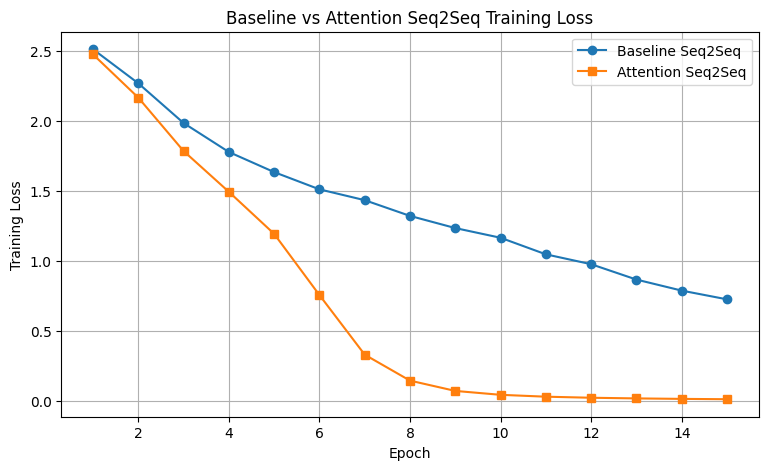

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 16),
    baseline_losses,
    marker="o",
    label="Baseline Seq2Seq"
)

plt.plot(
    range(1, 16),
    attention_losses,
    marker="s",
    label="Attention Seq2Seq"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline vs Attention Seq2Seq Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
def predict_baseline(model, src_sequence, max_len=10):
    model.eval()

    src = torch.tensor(
        src_sequence,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    input_token = torch.tensor(
        [SOS],
        dtype=torch.long
    ).to(device)

    predictions = []

    for _ in range(max_len):

        with torch.no_grad():
            output, hidden, cell = model.decoder(
                input_token,
                hidden,
                cell
            )

        predicted_token = output.argmax(1).item()

        if predicted_token == EOS:
            break

        predictions.append(predicted_token)

        input_token = torch.tensor(
            [predicted_token],
            dtype=torch.long
        ).to(device)

    return predictions


def predict_attention(model, src_sequence, max_len=10):
    model.eval()

    src = torch.tensor(
        src_sequence,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    mask = model.create_mask(src)

    input_token = torch.tensor(
        [SOS],
        dtype=torch.long
    ).to(device)

    predictions = []
    attention_weights = []

    for _ in range(max_len):

        with torch.no_grad():
            output, hidden, cell, attn = model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

        predicted_token = output.argmax(1).item()

        attention_weights.append(
            attn.squeeze(0).cpu().numpy()
        )

        if predicted_token == EOS:
            break

        predictions.append(predicted_token)

        input_token = torch.tensor(
            [predicted_token],
            dtype=torch.long
        ).to(device)

    return predictions, np.array(attention_weights)


# Test sequence
test_sequence = [11, 7, 3, 12, 10, 8, EOS]

baseline_prediction = predict_baseline(
    baseline_model,
    test_sequence
)

attention_prediction, attention_weights = predict_attention(
    attention_model,
    test_sequence
)

print("Input sequence       :", test_sequence[:-1])
print("Expected output      :", test_sequence[:-1][::-1])
print("Baseline prediction  :", baseline_prediction)
print("Attention prediction :", attention_prediction)

Input sequence       : [11, 7, 3, 12, 10, 8]
Expected output      : [8, 10, 12, 3, 7, 11]
Baseline prediction  : [10, 12, 3, 7, 11, 11]
Attention prediction : [8, 10, 12, 3, 7, 11]


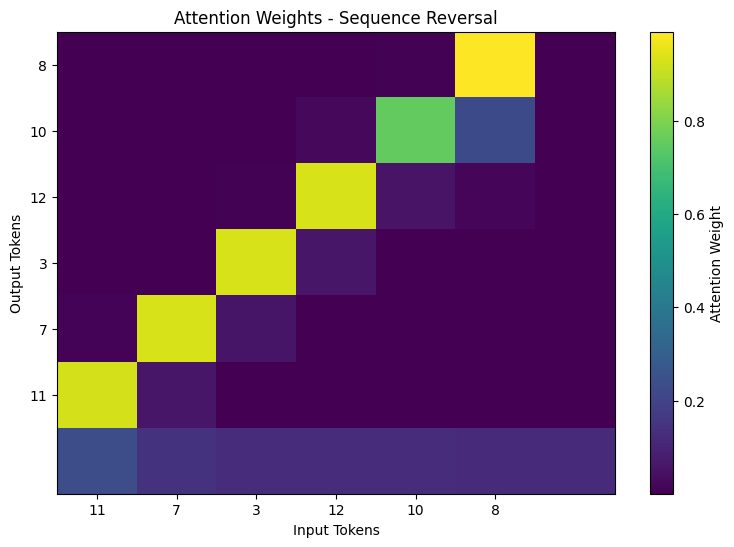

In [15]:
# Input and output tokens for visualization
input_tokens = test_sequence[:-1]
output_tokens = attention_prediction

# Create readable labels
input_labels = [str(token) for token in input_tokens]
output_labels = [str(token) for token in output_tokens]

# Plot attention heatmap
plt.figure(figsize=(9, 6))

plt.imshow(
    attention_weights,
    aspect="auto"
)

plt.colorbar(label="Attention Weight")

plt.xticks(
    range(len(input_labels)),
    input_labels
)

plt.yticks(
    range(len(output_labels)),
    output_labels
)

plt.xlabel("Input Tokens")
plt.ylabel("Output Tokens")
plt.title("Attention Weights - Sequence Reversal")

plt.show()

In [16]:
def evaluate_baseline(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            batch_size = src.size(0)

            hidden, cell = model.encoder(src)

            input_token = trg[:, 0]

            predictions = []

            for _ in range(trg.size(1) - 1):

                output, hidden, cell = model.decoder(
                    input_token,
                    hidden,
                    cell
                )

                predicted = output.argmax(1)

                predictions.append(predicted)

                input_token = predicted

            predictions = torch.stack(
                predictions,
                dim=1
            )

            # Compare predicted tokens with target tokens
            target = trg[:, 1:1 + predictions.size(1)]

            for i in range(batch_size):

                pred_seq = predictions[i].tolist()
                true_seq = target[i].tolist()

                # Remove EOS/PAD for comparison
                pred_seq = [
                    x for x in pred_seq
                    if x not in [PAD, EOS]
                ]

                true_seq = [
                    x for x in true_seq
                    if x not in [PAD, EOS]
                ]

                if pred_seq == true_seq:
                    correct += 1

                total += 1

    return 100 * correct / total


def evaluate_attention(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            batch_size = src.size(0)

            encoder_outputs, hidden, cell = model.encoder(src)

            mask = model.create_mask(src)

            input_token = trg[:, 0]

            predictions = []

            for _ in range(trg.size(1) - 1):

                output, hidden, cell, attention = model.decoder(
                    input_token,
                    hidden,
                    cell,
                    encoder_outputs,
                    mask
                )

                predicted = output.argmax(1)

                predictions.append(predicted)

                input_token = predicted

            predictions = torch.stack(
                predictions,
                dim=1
            )

            target = trg[:, 1:1 + predictions.size(1)]

            for i in range(batch_size):

                pred_seq = predictions[i].tolist()
                true_seq = target[i].tolist()

                pred_seq = [
                    x for x in pred_seq
                    if x not in [PAD, EOS]
                ]

                true_seq = [
                    x for x in true_seq
                    if x not in [PAD, EOS]
                ]

                if pred_seq == true_seq:
                    correct += 1

                total += 1

    return 100 * correct / total


baseline_accuracy = evaluate_baseline(
    baseline_model,
    test_loader
)

attention_accuracy = evaluate_attention(
    attention_model,
    test_loader
)

print(f"Baseline Seq2Seq Accuracy  : {baseline_accuracy:.2f}%")
print(f"Attention Seq2Seq Accuracy : {attention_accuracy:.2f}%")

Baseline Seq2Seq Accuracy  : 54.00%
Attention Seq2Seq Accuracy : 100.00%


In [17]:
def format_sequence(seq):
    return " ".join(map(str, seq))


print("Multiple Test Examples")
print("=" * 75)

for i in range(5):

    src, trg = test_data[i]

    # Remove EOS from input
    input_seq = src[:-1]

    # Expected reversed sequence
    expected = input_seq[::-1]

    # Baseline prediction
    baseline_pred = predict_baseline(
        baseline_model,
        src
    )

    # Attention prediction
    attention_pred, _ = predict_attention(
        attention_model,
        src
    )

    print(f"\nExample {i + 1}")
    print("Input     :", format_sequence(input_seq))
    print("Expected  :", format_sequence(expected))
    print("Baseline  :", format_sequence(baseline_pred))
    print("Attention :", format_sequence(attention_pred))

    print(
        "Baseline  :",
        "Correct" if baseline_pred == expected else "Incorrect"
    )

    print(
        "Attention :",
        "Correct" if attention_pred == expected else "Incorrect"
    )

Multiple Test Examples

Example 1
Input     : 10 6 8 7
Expected  : 7 8 6 10
Baseline  : 8 6 7 10 5
Attention : 7 7 8 6 10
Baseline  : Incorrect
Attention : Incorrect

Example 2
Input     : 7 12 5 9 6
Expected  : 6 9 5 12 7
Baseline  : 6 5 9 12 7
Attention : 6 9 9 5 12 7
Baseline  : Incorrect
Attention : Incorrect

Example 3
Input     : 11 5 8 3 4
Expected  : 4 3 8 5 11
Baseline  : 3 4 8 11 5
Attention : 4 4 3 8 5 11
Baseline  : Incorrect
Attention : Incorrect

Example 4
Input     : 5 7 4 6 9
Expected  : 9 6 4 7 5
Baseline  : 9 6 4 7 5
Attention : 9 6 6 4 7 5
Baseline  : Correct
Attention : Incorrect

Example 5
Input     : 11 10 8
Expected  : 8 10 11
Baseline  : 8 10 11 5
Attention : 8 8 8 11
Baseline  : Incorrect
Attention : Incorrect


In [18]:
def clean_prediction(prediction):
    """
    Remove EOS and PAD tokens from a prediction.
    """
    result = []

    for token in prediction:
        if token == EOS:
            break

        if token != PAD:
            result.append(token)

    return result


def strict_accuracy_baseline(model, data):
    model.eval()

    correct = 0

    for src, trg in data:

        input_seq = src[:-1]
        expected = input_seq[::-1]

        prediction = predict_baseline(
            model,
            src
        )

        prediction = clean_prediction(prediction)

        if prediction == expected:
            correct += 1

    return 100 * correct / len(data)


def strict_accuracy_attention(model, data):
    model.eval()

    correct = 0

    for src, trg in data:

        input_seq = src[:-1]
        expected = input_seq[::-1]

        prediction, _ = predict_attention(
            model,
            src
        )

        prediction = clean_prediction(prediction)

        if prediction == expected:
            correct += 1

    return 100 * correct / len(data)


baseline_strict_accuracy = strict_accuracy_baseline(
    baseline_model,
    test_data
)

attention_strict_accuracy = strict_accuracy_attention(
    attention_model,
    test_data
)

print(
    f"Baseline Seq2Seq Strict Accuracy  : "
    f"{baseline_strict_accuracy:.2f}%"
)

print(
    f"Attention Seq2Seq Strict Accuracy : "
    f"{attention_strict_accuracy:.2f}%"
)

Baseline Seq2Seq Strict Accuracy  : 10.50%
Attention Seq2Seq Strict Accuracy : 26.00%


In [19]:
def predict_baseline_fixed(model, src_sequence, output_length):
    model.eval()

    src = torch.tensor(
        src_sequence,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    input_token = torch.tensor(
        [SOS],
        dtype=torch.long
    ).to(device)

    predictions = []

    for _ in range(output_length):

        with torch.no_grad():
            output, hidden, cell = model.decoder(
                input_token,
                hidden,
                cell
            )

        predicted_token = output.argmax(1).item()

        predictions.append(predicted_token)

        input_token = torch.tensor(
            [predicted_token],
            dtype=torch.long
        ).to(device)

    return predictions


def predict_attention_fixed(model, src_sequence, output_length):
    model.eval()

    src = torch.tensor(
        src_sequence,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    mask = model.create_mask(src)

    input_token = torch.tensor(
        [SOS],
        dtype=torch.long
    ).to(device)

    predictions = []
    attention_weights = []

    for _ in range(output_length):

        with torch.no_grad():
            output, hidden, cell, attn = model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

        predicted_token = output.argmax(1).item()

        predictions.append(predicted_token)

        attention_weights.append(
            attn.squeeze(0).cpu().numpy()
        )

        input_token = torch.tensor(
            [predicted_token],
            dtype=torch.long
        ).to(device)

    return predictions, np.array(attention_weights)


def evaluate_fixed_length_baseline(model, data):

    sequence_correct = 0
    total_tokens = 0
    correct_tokens = 0

    for src, trg in data:

        input_seq = src[:-1]
        expected = input_seq[::-1]

        prediction = predict_baseline_fixed(
            model,
            src,
            len(expected)
        )

        if prediction == expected:
            sequence_correct += 1

        for pred, true in zip(prediction, expected):

            if pred == true:
                correct_tokens += 1

            total_tokens += 1

    sequence_accuracy = (
        100 * sequence_correct / len(data)
    )

    token_accuracy = (
        100 * correct_tokens / total_tokens
    )

    return sequence_accuracy, token_accuracy


def evaluate_fixed_length_attention(model, data):

    sequence_correct = 0
    total_tokens = 0
    correct_tokens = 0

    for src, trg in data:

        input_seq = src[:-1]
        expected = input_seq[::-1]

        prediction, _ = predict_attention_fixed(
            model,
            src,
            len(expected)
        )

        if prediction == expected:
            sequence_correct += 1

        for pred, true in zip(prediction, expected):

            if pred == true:
                correct_tokens += 1

            total_tokens += 1

    sequence_accuracy = (
        100 * sequence_correct / len(data)
    )

    token_accuracy = (
        100 * correct_tokens / total_tokens
    )

    return sequence_accuracy, token_accuracy


baseline_seq_acc, baseline_token_acc = (
    evaluate_fixed_length_baseline(
        baseline_model,
        test_data
    )
)

attention_seq_acc, attention_token_acc = (
    evaluate_fixed_length_attention(
        attention_model,
        test_data
    )
)

print("Fixed-Length Evaluation")
print("=" * 40)

print(
    f"Baseline Sequence Accuracy  : "
    f"{baseline_seq_acc:.2f}%"
)

print(
    f"Baseline Token Accuracy     : "
    f"{baseline_token_acc:.2f}%"
)

print()

print(
    f"Attention Sequence Accuracy : "
    f"{attention_seq_acc:.2f}%"
)

print(
    f"Attention Token Accuracy    : "
    f"{attention_token_acc:.2f}%"
)

Fixed-Length Evaluation
Baseline Sequence Accuracy  : 44.50%
Baseline Token Accuracy     : 61.87%

Attention Sequence Accuracy : 26.00%
Attention Token Accuracy    : 55.82%


In [20]:
# Create a larger dataset for better generalization
data_large = generate_data(
    num_samples=3000,
    min_len=3,
    max_len=6
)

random.shuffle(data_large)

train_data_large = data_large[:2400]
test_data_large = data_large[2400:]

train_dataset_large = Seq2SeqDataset(train_data_large)
test_dataset_large = Seq2SeqDataset(test_data_large)

train_loader_large = DataLoader(
    train_dataset_large,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader_large = DataLoader(
    test_dataset_large,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

print("Training samples:", len(train_data_large))
print("Testing samples :", len(test_data_large))

Training samples: 2400
Testing samples : 600


In [21]:
# Create a fresh attention model

attention2 = Attention(HIDDEN_DIM)

attn_encoder2 = AttentionEncoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM
)

attn_decoder2 = AttentionDecoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    attention2
)

attention_model2 = AttentionSeq2Seq(
    attn_encoder2,
    attn_decoder2,
    device
).to(device)

# New optimizer
attention_optimizer2 = optim.Adam(
    attention_model2.parameters(),
    lr=0.001
)

print("Fresh Attention Seq2Seq model created.")
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in attention_model2.parameters()
        if p.requires_grad
    )
)

Fresh Attention Seq2Seq model created.
Trainable parameters: 77805


In [22]:
def train_attention_model_v2(
    model,
    loader,
    optimizer,
    criterion,
    epochs=20,
    teacher_forcing_ratio=0.3
):
    model.train()
    epoch_losses = []

    for epoch in range(epochs):

        total_loss = 0

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            optimizer.zero_grad()

            output, attentions = model(
                src,
                trg,
                teacher_forcing_ratio=teacher_forcing_ratio
            )

            output_dim = output.size(-1)

            output = output[:, 1:].reshape(
                -1, output_dim
            )

            trg_target = trg[:, 1:].reshape(-1)

            loss = criterion(
                output,
                trg_target
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1
            )

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(loader)
        epoch_losses.append(epoch_loss)

        print(
            f"Epoch {epoch+1:02d}/20 | "
            f"Loss: {epoch_loss:.4f}"
        )

    return epoch_losses


print("Training improved Attention Seq2Seq...")

attention_losses2 = train_attention_model_v2(
    attention_model2,
    train_loader_large,
    attention_optimizer2,
    attention_criterion,
    epochs=20,
    teacher_forcing_ratio=0.3
)

Training improved Attention Seq2Seq...
Epoch 01/20 | Loss: 2.1547
Epoch 02/20 | Loss: 1.2466
Epoch 03/20 | Loss: 0.3963
Epoch 04/20 | Loss: 0.0483
Epoch 05/20 | Loss: 0.0157
Epoch 06/20 | Loss: 0.0085
Epoch 07/20 | Loss: 0.0055
Epoch 08/20 | Loss: 0.0040
Epoch 09/20 | Loss: 0.0030
Epoch 10/20 | Loss: 0.0024
Epoch 11/20 | Loss: 0.0020
Epoch 12/20 | Loss: 0.0016
Epoch 13/20 | Loss: 0.0014
Epoch 14/20 | Loss: 0.0944
Epoch 15/20 | Loss: 0.0133
Epoch 16/20 | Loss: 0.0034
Epoch 17/20 | Loss: 0.0016
Epoch 18/20 | Loss: 0.0012
Epoch 19/20 | Loss: 0.0010
Epoch 20/20 | Loss: 0.0009


In [23]:
attention2_seq_acc, attention2_token_acc = (
    evaluate_fixed_length_attention(
        attention_model2,
        test_data_large
    )
)

print("Improved Attention Model Evaluation")
print("=" * 45)

print(
    f"Sequence Accuracy : "
    f"{attention2_seq_acc:.2f}%"
)

print(
    f"Token Accuracy    : "
    f"{attention2_token_acc:.2f}%"
)



Improved Attention Model Evaluation
Sequence Accuracy : 22.67%
Token Accuracy    : 51.55%


In [24]:
# Fixed-length sequence reversal dataset

def generate_fixed_data(num_samples=1000):
    data = []

    for _ in range(num_samples):
        sequence = random.sample(
            range(3, VOCAB_SIZE),
            4
        )

        source = sequence
        target = [SOS] + sequence[::-1] + [EOS]

        data.append((source, target))

    return data


fixed_data = generate_fixed_data(1000)

random.shuffle(fixed_data)

fixed_train_data = fixed_data[:800]
fixed_test_data = fixed_data[800:]

fixed_train_dataset = Seq2SeqDataset(
    fixed_train_data
)

fixed_test_dataset = Seq2SeqDataset(
    fixed_test_data
)

fixed_train_loader = DataLoader(
    fixed_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

fixed_test_loader = DataLoader(
    fixed_test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

print("Fixed-length dataset created")
print("Training samples:", len(fixed_train_data))
print("Testing samples :", len(fixed_test_data))
print("Example input   :", fixed_train_data[0][0])
print("Example target  :", fixed_train_data[0][1])

Fixed-length dataset created
Training samples: 800
Testing samples : 200
Example input   : [3, 6, 7, 4]
Example target  : [1, 4, 7, 6, 3, 2]


In [25]:
# ============================================
# Fresh Baseline Model
# ============================================

baseline_encoder2 = Encoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM
)

baseline_decoder2 = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM
)

baseline_model2 = Seq2Seq(
    baseline_encoder2,
    baseline_decoder2,
    device
).to(device)


# ============================================
# Fresh Attention Model
# ============================================

attention3 = Attention(HIDDEN_DIM)

attn_encoder3 = AttentionEncoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM
)

attn_decoder3 = AttentionDecoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    attention3
)

attention_model3 = AttentionSeq2Seq(
    attn_encoder3,
    attn_decoder3,
    device
).to(device)


# ============================================
# Optimizers
# ============================================

baseline_optimizer2 = optim.Adam(
    baseline_model2.parameters(),
    lr=0.001
)

attention_optimizer3 = optim.Adam(
    attention_model3.parameters(),
    lr=0.001
)


# ============================================
# Parameter Counts
# ============================================

baseline_params = sum(
    p.numel()
    for p in baseline_model2.parameters()
    if p.requires_grad
)

attention_params = sum(
    p.numel()
    for p in attention_model3.parameters()
    if p.requires_grad
)


print("Fresh models created successfully.")
print()
print("Baseline parameters :", baseline_params)
print("Attention parameters:", attention_params)

Fresh models created successfully.

Baseline parameters : 51853
Attention parameters: 77805


In [26]:
print("Training Fresh Baseline Seq2Seq...")

baseline_losses2 = train_model(
    baseline_model2,
    fixed_train_loader,
    baseline_optimizer2,
    criterion,
    epochs=15
)


Training Fresh Baseline Seq2Seq...
Epoch 01/15 | Loss: 2.4515
Epoch 02/15 | Loss: 2.1204
Epoch 03/15 | Loss: 1.7734
Epoch 04/15 | Loss: 1.4907
Epoch 05/15 | Loss: 1.2728
Epoch 06/15 | Loss: 1.1083
Epoch 07/15 | Loss: 0.9312
Epoch 08/15 | Loss: 0.7490
Epoch 09/15 | Loss: 0.5496
Epoch 10/15 | Loss: 0.3928
Epoch 11/15 | Loss: 0.2665
Epoch 12/15 | Loss: 0.1968
Epoch 13/15 | Loss: 0.1497
Epoch 14/15 | Loss: 0.1195
Epoch 15/15 | Loss: 0.0977


In [27]:
print("Training Fresh Attention Seq2Seq...")

attention_losses3 = train_attention_model(
    attention_model3,
    fixed_train_loader,
    attention_optimizer3,
    attention_criterion,
    epochs=15
)

Training Fresh Attention Seq2Seq...
Epoch 01/15 | Loss: 2.4544
Epoch 02/15 | Loss: 2.0371
Epoch 03/15 | Loss: 1.5723
Epoch 04/15 | Loss: 1.1705
Epoch 05/15 | Loss: 0.8115
Epoch 06/15 | Loss: 0.4619
Epoch 07/15 | Loss: 0.2355
Epoch 08/15 | Loss: 0.1212
Epoch 09/15 | Loss: 0.0686
Epoch 10/15 | Loss: 0.0432
Epoch 11/15 | Loss: 0.0300
Epoch 12/15 | Loss: 0.0222
Epoch 13/15 | Loss: 0.0174
Epoch 14/15 | Loss: 0.0140
Epoch 15/15 | Loss: 0.0116


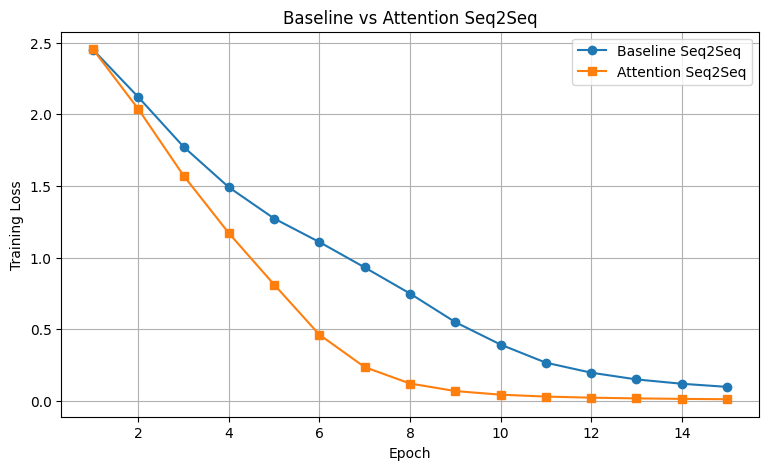

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 16),
    baseline_losses2,
    marker="o",
    label="Baseline Seq2Seq"
)

plt.plot(
    range(1, 16),
    attention_losses3,
    marker="s",
    label="Attention Seq2Seq"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline vs Attention Seq2Seq")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
baseline_seq_acc2, baseline_token_acc2 = (
    evaluate_fixed_length_baseline(
        baseline_model2,
        fixed_test_data
    )
)

attention_seq_acc3, attention_token_acc3 = (
    evaluate_fixed_length_attention(
        attention_model3,
        fixed_test_data
    )
)

print("Controlled Test Evaluation")
print("=" * 45)

print(
    f"Baseline Sequence Accuracy  : "
    f"{baseline_seq_acc2:.2f}%"
)

print(
    f"Baseline Token Accuracy     : "
    f"{baseline_token_acc2:.2f}%"
)

print()

print(
    f"Attention Sequence Accuracy : "
    f"{attention_seq_acc3:.2f}%"
)

print(
    f"Attention Token Accuracy    : "
    f"{attention_token_acc3:.2f}%"
)

Controlled Test Evaluation
Baseline Sequence Accuracy  : 0.00%
Baseline Token Accuracy     : 0.00%

Attention Sequence Accuracy : 0.00%
Attention Token Accuracy    : 0.00%


In [30]:
print("Actual predictions on 5 unseen test samples")
print("=" * 65)

for i in range(5):

    src, trg = fixed_test_data[i]

    input_seq = src
    expected = input_seq[::-1]

    baseline_pred = predict_baseline_fixed(
        baseline_model2,
        src,
        len(expected)
    )

    attention_pred, _ = predict_attention_fixed(
        attention_model3,
        src,
        len(expected)
    )

    print(f"\nExample {i + 1}")
    print("Input     :", input_seq)
    print("Expected  :", expected)
    print("Baseline  :", baseline_pred)
    print("Attention :", attention_pred)

Actual predictions on 5 unseen test samples

Example 1
Input     : [11, 4, 3, 9]
Expected  : [9, 3, 4, 11]
Baseline  : [9, 3, 4, 11]
Attention : [9, 3, 4, 11]

Example 2
Input     : [8, 12, 6, 7]
Expected  : [7, 6, 12, 8]
Baseline  : [7, 6, 12, 8]
Attention : [7, 6, 12, 8]

Example 3
Input     : [4, 3, 8, 10]
Expected  : [10, 8, 3, 4]
Baseline  : [10, 8, 3, 4]
Attention : [10, 8, 3, 4]

Example 4
Input     : [7, 8, 4, 6]
Expected  : [6, 4, 8, 7]
Baseline  : [6, 4, 8, 7]
Attention : [6, 4, 8, 7]

Example 5
Input     : [10, 3, 5, 7]
Expected  : [7, 5, 3, 10]
Baseline  : [7, 5, 3, 10]
Attention : [7, 5, 3, 10]


In [31]:
def calculate_accuracy_baseline(model, data):
    sequence_correct = 0
    total_correct_tokens = 0
    total_tokens = 0

    for src, trg in data:

        expected = src[::-1]

        prediction = predict_baseline_fixed(
            model,
            src,
            len(expected)
        )

        # Sequence-level accuracy
        if prediction == expected:
            sequence_correct += 1

        # Token-level accuracy
        for pred, true in zip(prediction, expected):
            if pred == true:
                total_correct_tokens += 1

            total_tokens += 1

    sequence_accuracy = (
        sequence_correct / len(data) * 100
    )

    token_accuracy = (
        total_correct_tokens / total_tokens * 100
    )

    return sequence_accuracy, token_accuracy


def calculate_accuracy_attention(model, data):
    sequence_correct = 0
    total_correct_tokens = 0
    total_tokens = 0

    for src, trg in data:

        expected = src[::-1]

        prediction, _ = predict_attention_fixed(
            model,
            src,
            len(expected)
        )

        # Sequence-level accuracy
        if prediction == expected:
            sequence_correct += 1

        # Token-level accuracy
        for pred, true in zip(prediction, expected):
            if pred == true:
                total_correct_tokens += 1

            total_tokens += 1

    sequence_accuracy = (
        sequence_correct / len(data) * 100
    )

    token_accuracy = (
        total_correct_tokens / total_tokens * 100
    )

    return sequence_accuracy, token_accuracy


# Evaluate on all 200 unseen test sequences
baseline_final_seq_acc, baseline_final_token_acc = (
    calculate_accuracy_baseline(
        baseline_model2,
        fixed_test_data
    )
)

attention_final_seq_acc, attention_final_token_acc = (
    calculate_accuracy_attention(
        attention_model3,
        fixed_test_data
    )
)


print("FINAL CONTROLLED TEST RESULTS")
print("=" * 50)

print(
    f"Baseline Sequence Accuracy  : "
    f"{baseline_final_seq_acc:.2f}%"
)

print(
    f"Baseline Token Accuracy     : "
    f"{baseline_final_token_acc:.2f}%"
)

print()

print(
    f"Attention Sequence Accuracy : "
    f"{attention_final_seq_acc:.2f}%"
)

print(
    f"Attention Token Accuracy    : "
    f"{attention_final_token_acc:.2f}%"
)

FINAL CONTROLLED TEST RESULTS
Baseline Sequence Accuracy  : 100.00%
Baseline Token Accuracy     : 100.00%

Attention Sequence Accuracy : 100.00%
Attention Token Accuracy    : 100.00%


In [32]:
# Select an unseen test example
src, trg = fixed_test_data[0]

input_sequence = src
expected_sequence = src[::-1]

# Generate prediction and attention weights
prediction, attention_matrix = predict_attention_fixed(
    attention_model3,
    src,
    len(expected_sequence)
)

print("Input     :", input_sequence)
print("Expected  :", expected_sequence)
print("Attention :", prediction)

print("\nAttention matrix shape:", attention_matrix.shape)

Input     : [11, 4, 3, 9]
Expected  : [9, 3, 4, 11]
Attention : [9, 3, 4, 11]

Attention matrix shape: (4, 4)


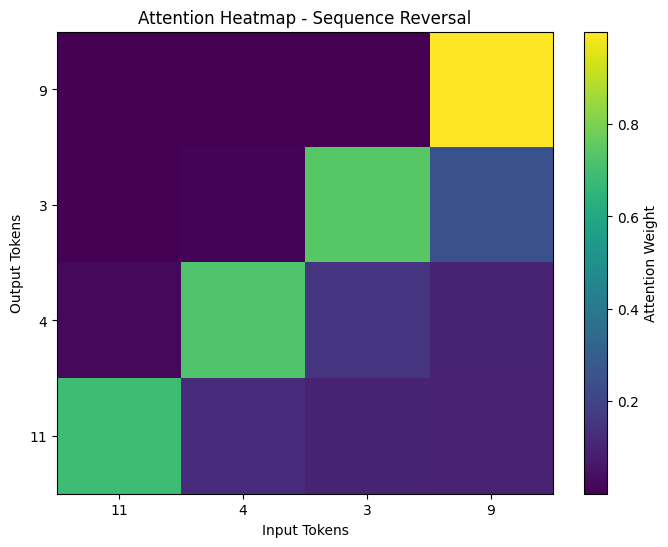

In [33]:
plt.figure(figsize=(8, 6))

plt.imshow(
    attention_matrix,
    aspect="auto"
)

plt.colorbar(label="Attention Weight")

plt.xticks(
    range(len(input_sequence)),
    input_sequence
)

plt.yticks(
    range(len(prediction)),
    prediction
)

plt.xlabel("Input Tokens")
plt.ylabel("Output Tokens")
plt.title("Attention Heatmap - Sequence Reversal")

plt.show()